<a href="https://colab.research.google.com/github/hodatisg520/DL4AI-240112-project/blob/main/final_project_dl4ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# Your code goes here

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Đọc dữ liệu
df = pd.read_csv('AAL.csv')

df.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,27-09-2005,19.100000,21.049999,961200,21.400000,19.299999,18.194910
1,28-09-2005,19.200001,19.299999,5747900,20.530001,20.500000,19.326204
2,29-09-2005,20.100000,20.400000,1078200,20.580000,20.209999,19.052805
3,30-09-2005,20.180000,20.260000,3123300,21.049999,21.010000,19.807001
4,03-10-2005,20.900000,20.900000,1057900,21.750000,21.500000,20.268940


In [4]:
# Get some info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4333 entries, 0 to 4332
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4333 non-null   object 
 1   Low             4333 non-null   float64
 2   Open            4333 non-null   float64
 3   Volume          4333 non-null   int64  
 4   High            4333 non-null   float64
 5   Close           4333 non-null   float64
 6   Adjusted Close  4333 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 237.1+ KB


In [6]:
# Chọn 6 đặc trưng theo yêu cầu đề bài
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
dataset = df[features].values

# 2. Chuẩn hóa dữ liệu (Scaling)
# Dùng 2 scaler riêng biệt để dễ dàng khôi phục giá trị dự đoán về đơn vị gốc
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_features.fit_transform(dataset)
# Giả sử ta muốn dự đoán giá 'Close' (cột index 3)
target_col_idx = 3
scaler_target.fit(dataset[:, target_col_idx].reshape(-1, 1))

MinMaxScaler()

In [7]:
def create_dataset(data, target_idx, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        # X chứa 6 đặc trưng của 'time_step' ngày trước đó
        X.append(data[i-time_step:i, :])
        # y là giá mục tiêu của ngày hiện tại
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

time_step = 60 # Sử dụng 60 ngày quá khứ để dự đoán [cite: 817]
X, y = create_dataset(scaled_features, target_col_idx, time_step)

# Chia tập Train/Test theo trình tự thời gian
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [8]:
model = Sequential([
    # Input shape: (số bước thời gian, số đặc trưng) -> (60, 6)
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Chống overfitting [cite: 1012]

    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    Dense(units=25),
    Dense(units=1) # Dự đoán 1 giá trị đầu ra
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Huấn luyện mô hình
model.fit(X_train, y_train, batch_size=32, epochs=50, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0076 - val_loss: 0.0013
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0032 - val_loss: 6.3452e-04
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025 - val_loss: 6.0369e-04
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0023 - val_loss: 9.5765e-04
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0018 - val_loss: 7.8862e-04
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 6.1515e-04
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 8.0282e-04
Epoch 9/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 5.8732e-04
Epoch 10/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 7.3011e-04
Epoch 11/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 7.7051e-04
Epoch

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


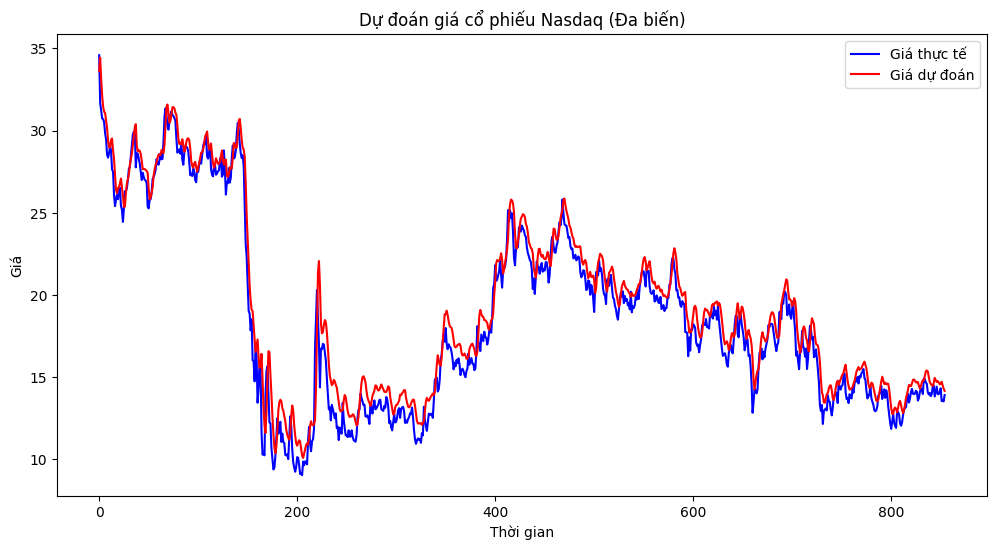

In [9]:
# Dự đoán trên tập test
predictions = model.predict(X_test)

# Chuyển ngược về giá trị thực tế
predictions_rescaled = scaler_target.inverse_transform(predictions)
y_test_rescaled = scaler_target.inverse_transform(y_test.reshape(-1, 1))

# Vẽ biểu đồ so sánh [cite: 11]
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, color='blue', label='Giá thực tế')
plt.plot(predictions_rescaled, color='red', label='Giá dự đoán')
plt.title('Dự đoán giá cổ phiếu Nasdaq (Đa biến)')
plt.xlabel('Thời gian')
plt.ylabel('Giá')
plt.legend()
plt.show()